# Pancreatic Endocrinogenesis Reference Analysis

This notebook uses pancreas reference outputs produced from the provided stage-1 and stage-2 checkpoints. It reads checkpoint-derived reference CSV/H5AD/attention files and does not train new model weights.


In [ ]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import pandas as pd
from scipy import sparse

PROJECT = Path.cwd().resolve()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent

REFERENCE_DIR = PROJECT / "data" / "pancreas" / "reference_outputs"
CHECKPOINT_DIR = PROJECT / "data" / "pancreas" / "reference_checkpoints"
STAGE1_CKPT = CHECKPOINT_DIR / "pancreas_stage1.ckpt"
STAGE2_CKPT = CHECKPOINT_DIR / "pancreas_stage2.ckpt"
GENE_ORDER = CHECKPOINT_DIR / "pancreas_genes.txt"
STAGE1_CSV = REFERENCE_DIR / "pancreas_stage1_reference.csv"
STAGE2_CSV = REFERENCE_DIR / "pancreas_stage2_reference.csv"
ATTENTION_H5AD = REFERENCE_DIR / "pancreas_attention_scores.h5ad"
INSULIN_ACTIVITY_CSV = REFERENCE_DIR / "pancreas_insulin_signaling_attention_activity.csv"
MEAN_ATTENTION_DIR = REFERENCE_DIR / "pancreas_mean_attention_by_celltype"
BETA_MEAN_ATTENTION_NPZ = MEAN_ATTENTION_DIR / "Beta_mean_attention.npz"
FIGURE_DIR = PROJECT / "outputs" / "pancreas_reference_notebook_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    STAGE1_CKPT,
    STAGE2_CKPT,
    GENE_ORDER,
    STAGE1_CSV,
    STAGE2_CSV,
    ATTENTION_H5AD,
    INSULIN_ACTIVITY_CSV,
    BETA_MEAN_ATTENTION_NPZ,
]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

CELLTYPE_ORDER = ["Ductal", "Ngn3Low", "Ngn3High", "Pre-endocrine", "Alpha", "Beta", "Delta", "Epsilon"]
RANK_GROUP_ORDER = ["Ngn3Low", "Beta", "Alpha", "Ductal", "Ngn3High", "Delta", "Epsilon", "Pre-endocrine"]
CELLTYPE_DISPLAY = {"Ngn3Low": "Ngn3Low", "Ngn3High": "Ngn3High"}

STAGE1_CSV, STAGE2_CSV, ATTENTION_H5AD, INSULIN_ACTIVITY_CSV, BETA_MEAN_ATTENTION_NPZ, FIGURE_DIR


## What The Attention Score Means

`pancreas_attention_scores.h5ad` stores per-cell attention-derived regulator scores for the pancreas reference. For each regulator in the prior network, the score sums attention from that regulator to its prior targets, after retaining regulators that appear in the top 10% attention columns for at least one target gene. Rows are cells and columns are regulators.

For reproducible checkpoint-based analysis, keep the gene order paired with the released pancreas checkpoint and run inference/export from the provided checkpoint weights. The gene set can be identical while the index order differs, and checkpoint attention matrices are index-aligned.


## Shared Helpers

In [2]:
def as_dense(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)


def minmax_columns(values):
    values = np.asarray(values, dtype=float)
    mins = np.nanmin(values, axis=0)
    maxs = np.nanmax(values, axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1.0
    return (values - mins) / ranges


def display_celltype(name):
    return CELLTYPE_DISPLAY.get(name, name)


def title_case_gene(name):
    return name[:1].upper() + name[1:].lower()


def require_genes(adata, genes):
    genes_upper = [gene.upper() for gene in genes]
    available = [gene for gene in genes_upper if gene in adata.var_names]
    missing = [gene for gene in genes_upper if gene not in adata.var_names]
    if missing:
        print("Missing genes:", missing)
    return available

## Reference Output Preview

In [3]:
preview_cols = ["cellIndex", "gene_name", "unsplice", "splice", "unsplice_predict", "splice_predict", "clusters"]
stage1_preview = pd.read_csv(STAGE1_CSV, usecols=preview_cols, nrows=5)
stage2_preview = pd.read_csv(STAGE2_CSV, usecols=preview_cols, nrows=5)

display(stage1_preview)
display(stage2_preview)

,cellIndex,gene_name,unsplice,splice,unsplice_predict,splice_predict,clusters
0,0,0610010F05RIK,0.188744,0.240883,0.285733,0.230735,Pre-endocrine
1,1,0610010F05RIK,0.096946,0.108301,0.229186,0.108476,Ductal
2,2,0610010F05RIK,0.183575,0.251075,0.282041,0.235197,Alpha
3,3,0610010F05RIK,0.094704,0.174730,0.227560,0.150557,Ductal
4,4,0610010F05RIK,0.048288,0.233265,0.200468,0.170477,Ngn3 high EP


,cellIndex,gene_name,unsplice,splice,unsplice_predict,splice_predict,clusters
0,0,0610010F05RIK,0.188744,0.240883,0.170604,0.231052,Pre-endocrine
1,1,0610010F05RIK,0.096946,0.108301,0.104260,0.108127,Ductal
2,2,0610010F05RIK,0.183575,0.251075,0.163577,0.236625,Alpha
3,3,0610010F05RIK,0.094704,0.174730,0.101195,0.153775,Ductal
4,4,0610010F05RIK,0.048288,0.233265,0.076497,0.178194,Ngn3 high EP


## Dynamic Gene Importance Score

In [4]:
MARKER_GENES = [
    "FOXP2", "NEUROG3", "HMGN3", "PYY", "IAPP", "CPE", "GCG",
    "SLC38A5", "PDX1", "INS2", "SST", "HHEX", "GHRL",
]
MARKER_LABELS = {
    "FOXP2": "Foxp2",
    "NEUROG3": "Neurog3",
    "HMGN3": "Hmgn3",
    "PYY": "Pyy",
    "IAPP": "Iapp",
    "CPE": "Cpe",
    "GCG": "Gcg",
    "SLC38A5": "Slc38a5",
    "PDX1": "Pdx1",
    "INS2": "Ins2",
    "SST": "Sst",
    "HHEX": "Hhex",
    "GHRL": "Ghrl",
}

attention = ad.read_h5ad(ATTENTION_H5AD)
if "clusterid" not in attention.obs:
    attention.obs["clusterid"] = attention.obs["cell_type"].astype(str).map({
        "Ngn3 low EP": "Ngn3Low",
        "Ngn3 high EP": "Ngn3High",
    }).fillna(attention.obs["cell_type"].astype(str))

available_markers = require_genes(attention, MARKER_GENES)
marker_scores = as_dense(attention[:, available_markers].X)
marker_scores = minmax_columns(marker_scores)

score_df = pd.DataFrame(marker_scores, columns=available_markers, index=attention.obs_names)
score_df["clusterid"] = attention.obs["clusterid"].astype(str).values
score_df.head()

,FOXP2,NEUROG3,HMGN3,PYY,IAPP,CPE,GCG,SLC38A5,PDX1,INS2,SST,HHEX,GHRL,clusterid
0,0.755162,0.020473,0.004234,0.011028,0.016628,0.023333,0.015215,0.017793,0.080422,0.027896,0.021940,0.025587,0.014216,Ngn3Low
1,0.777351,0.024355,0.006867,0.009319,0.015361,0.023088,0.014962,0.016759,0.069372,0.029259,0.022845,0.069163,0.013144,Ngn3Low
2,0.881297,0.004649,0.010287,0.011557,0.018305,0.029824,0.019881,0.020477,0.134617,0.034727,0.028679,0.008866,0.017517,Ngn3Low
3,0.705656,0.051997,0.006194,0.010792,0.013806,0.023002,0.014517,0.016068,0.109997,0.026764,0.020390,0.021011,0.012446,Ngn3Low
4,0.694818,0.106666,0.006746,0.009698,0.013946,0.022039,0.013302,0.015491,0.117015,0.026374,0.019499,0.021170,0.012285,Ngn3Low


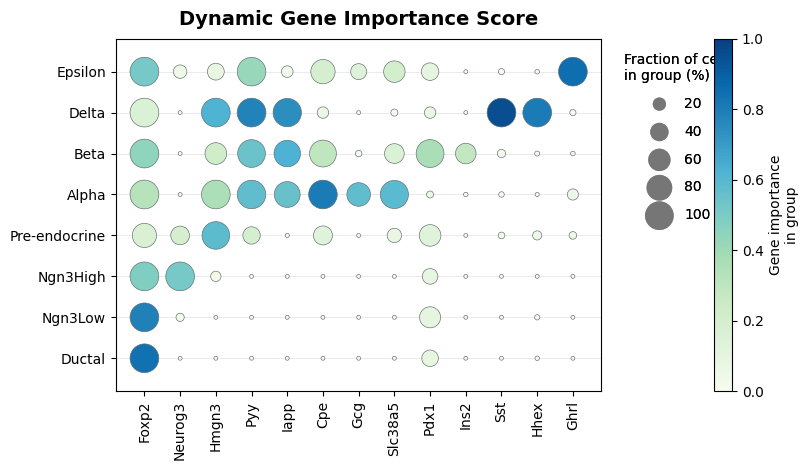

In [5]:
score_cutoff = 0.10
long_scores = score_df.melt(id_vars="clusterid", var_name="gene", value_name="score")
summary = (
    long_scores.groupby(["clusterid", "gene"], observed=True)
    .agg(
        mean_score=("score", "mean"),
        fraction=("score", lambda values: 100 * (values > score_cutoff).mean()),
    )
    .reset_index()
)

grid = pd.MultiIndex.from_product([CELLTYPE_ORDER, available_markers], names=["clusterid", "gene"]).to_frame(index=False)
summary = grid.merge(summary, on=["clusterid", "gene"], how="left").fillna({"mean_score": 0.0, "fraction": 0.0})
summary["x"] = summary["gene"].map({gene: idx for idx, gene in enumerate(available_markers)})
summary["y"] = summary["clusterid"].map({name: idx for idx, name in enumerate(CELLTYPE_ORDER)})

fig, ax = plt.subplots(figsize=(8.2, 4.8))
size_scale = 4.2
scatter = ax.scatter(
    summary["x"],
    summary["y"],
    s=8 + summary["fraction"] * size_scale,
    c=summary["mean_score"],
    cmap="GnBu",
    vmin=0,
    vmax=1,
    edgecolor="#5E6A6A",
    linewidth=0.45,
)

ax.set_title("Dynamic Gene Importance Score", fontsize=14, weight="bold", pad=10)
ax.set_xticks(range(len(available_markers)))
ax.set_xticklabels([MARKER_LABELS.get(gene, title_case_gene(gene)) for gene in available_markers], rotation=90)
ax.set_yticks(range(len(CELLTYPE_ORDER)))
ax.set_yticklabels([display_celltype(name) for name in CELLTYPE_ORDER])
ax.set_xlim(-0.8, len(available_markers) - 0.2)
ax.set_ylim(-0.8, len(CELLTYPE_ORDER) - 0.2)
ax.grid(axis="y", color="#E6E6E6", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

legend_levels = [20, 40, 60, 80, 100]
handles = [
    ax.scatter([], [], s=8 + level * size_scale, color="#6D6D6D", alpha=0.75, edgecolor="none")
    for level in legend_levels
]
size_legend = ax.legend(
    handles,
    [str(level) for level in legend_levels],
    title="Fraction of cells\nin group (%)",
    frameon=False,
    bbox_to_anchor=(1.02, 0.72),
    loc="center left",
    labelspacing=1.0,
)
ax.add_artist(size_legend)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.18)
cbar.set_label("Gene importance\nin group")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_d_dynamic_gene_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Insulin Signaling Pathway Activity

`INSULIN_ACTIVITY_CSV` is a precomputed per-cell table used to keep this tutorial lightweight. It stores the pathway activity values plus the cell metadata needed for plotting. The raw per-cell attention tensors used to make this table are larger than the notebook inputs and are not required for viewing the example analysis.

To recompute the table, save the raw per-cell stage-1 attention matrix before it is aggregated into TF-score or cell-type mean outputs, and use the same model gene order used by the checkpoint. The activity score is calculated by summing attention weights inside the insulin signaling gene set, restricted to regulator-target pairs present in the prior network. For one cell:

```python
score = 0.0
for target in INSULIN_SIGNALING_GENES:
    for regulator in INSULIN_SIGNALING_GENES:
        if (regulator.upper(), target.upper()) in prior_edges:
            score += attention[gene_to_idx[target.upper()], gene_to_idx[regulator.upper()]]
```

If the saved attention tensor has multiple heads or layers, first average it to a gene-by-gene matrix. Then write one row per cell with `cellIndex`, `pathway_activity`, `cellID`, `clusters`, `embedding1`, and `embedding2`.



In [6]:
INSULIN_SIGNALING_GENES = [
    "Ins2", "Pik3r1", "Pik3r3", "Akt3", "Calm2", "Calml4", "Pygl", "Pde3b",
    "Prkacb", "Prkar2a", "Prkar1b", "Exoc7", "Gck", "Foxo1", "G6pc2", "Bad",
    "Shc2", "Braf", "Mapk8", "Mapk10", "Inppl1", "Inpp5a",
]

pathway_activity = pd.read_csv(INSULIN_ACTIVITY_CSV)
pathway_activity.head()

,cellIndex,pathway_activity,cellID,clusters,embedding1,embedding2
0,0,0.979330,AAACCTGAGAGGGATA,Pre-endocrine,6.143066,-0.063644
1,1,1.099439,AAACCTGAGCCTTGAT,Ductal,-9.906417,0.197778
2,2,0.748969,AAACCTGAGGCAATTA,Alpha,7.559791,0.583762
3,3,1.272176,AAACCTGCATCATCCC,Ductal,-11.283765,4.218998
4,4,1.067271,AAACCTGGTAAGTGGC,Ngn3 high EP,1.721565,-4.753407


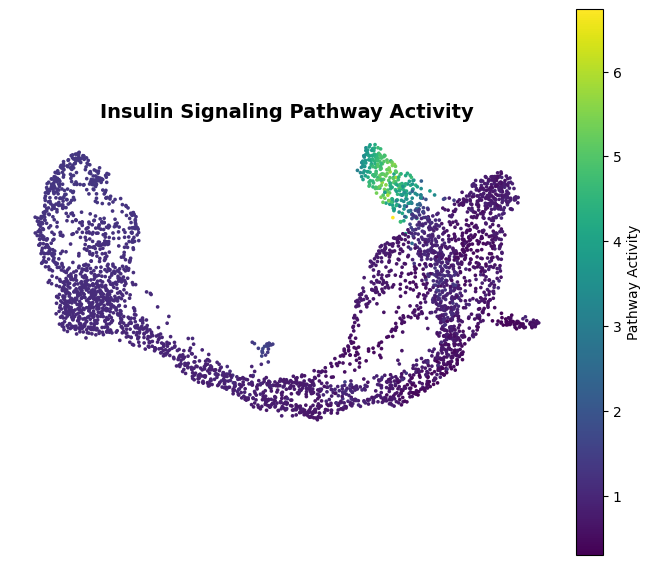

In [7]:
fig, ax = plt.subplots(figsize=(6.6, 5.8))
scatter = ax.scatter(
    pathway_activity["embedding1"],
    pathway_activity["embedding2"],
    c=pathway_activity["pathway_activity"],
    cmap="viridis",
    s=7,
    linewidth=0,
)
ax.set_title("Insulin Signaling Pathway Activity", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Pathway Activity")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_e_insulin_signaling_activity.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
pathway_activity_by_celltype = (
    pathway_activity.assign(clusterid=pathway_activity["clusters"].replace({
        "Ngn3 low EP": "Ngn3Low",
        "Ngn3 high EP": "Ngn3High",
    }))
    .groupby("clusterid", observed=True)["pathway_activity"]
    .describe()
    .reindex(CELLTYPE_ORDER)
)
pathway_activity_by_celltype

,count,mean,std,min,25%,50%,75%,max
clusterid,,,,,,,,
Ductal,916.0,1.173289,0.090704,1.009788,1.092108,1.157189,1.253498,1.331086
Ngn3Low,262.0,1.132525,0.105283,0.983953,1.052862,1.098461,1.219752,1.511620
Ngn3High,642.0,0.867863,0.161062,0.551875,0.754409,0.861131,0.955882,1.636565
Pre-endocrine,592.0,0.677295,0.175751,0.302864,0.553564,0.646192,0.781494,1.511066
Alpha,481.0,0.704523,0.148855,0.456200,0.579345,0.700906,0.803784,1.489411
Beta,591.0,2.473439,1.716618,0.501347,0.965723,1.358620,4.192955,6.732128
Delta,70.0,0.500472,0.132094,0.358377,0.399241,0.445940,0.581606,0.973334
Epsilon,142.0,0.715686,0.052275,0.593212,0.678203,0.711773,0.750364,0.834830


## Type-Specific TF Discovery

`scanpy.tl.rank_genes_groups` is run on the attention-derived regulator score matrix. Without `groups` or `reference`, Scanpy ranks each cell type against the rest of the dataset. The Beta list is then sorted by `logfoldchanges` in the Beta column.

In [9]:
attention_scores = attention.copy()
attention_scores.obs["clusterid"] = pd.Categorical(
    attention_scores.obs["clusterid"].astype(str),
    categories=RANK_GROUP_ORDER,
    ordered=True,
)
attention_scores


AnnData object with n_obs × n_vars = 3696 × 1791
    obs: 'clusterid', 'cell_type'

In [10]:
# Run Scanpy differential ranking on the attention score matrix.
sc.tl.rank_genes_groups(attention_scores, "clusterid", method="t-test", key_added="t-test", use_raw=False)
sc.tl.rank_genes_groups(
    attention_scores,
    "clusterid",
    method="t-test_overestim_var",
    key_added="t-test_ov",
    use_raw=False,
)
sc.tl.rank_genes_groups(
    attention_scores,
    "clusterid",
    method="wilcoxon",
    key_added="wilcoxon",
    use_raw=False,
    tie_correct=True,
)

beta_one_vs_rest = sc.get.rank_genes_groups_df(attention_scores, group="Beta", key="wilcoxon")
beta_one_vs_rest = beta_one_vs_rest.rename(columns={"names": "regulator"})
beta_one_vs_rest.to_csv(FIGURE_DIR / "beta_regulators_scanpy_wilcoxon_one_vs_rest.csv", index=False)
beta_specific_tfs = (
    beta_one_vs_rest.query("pvals_adj <= 0.05 and scores > 0")
    .sort_values("logfoldchanges", ascending=False)
    .head(30)
)
beta_specific_tfs.to_csv(FIGURE_DIR / "beta_specific_tfs_vs_rest_top30.csv", index=False)
display(beta_specific_tfs)

# Positional extraction from adata.uns["wilcoxon"].
# With RANK_GROUP_ORDER, index 0 is Ngn3Low and index 1 is Beta.
rank_groups_by_position = pd.DataFrame({
    "group_index": range(len(attention_scores.uns["wilcoxon"]["names"].dtype.names)),
    "group_name": list(attention_scores.uns["wilcoxon"]["names"].dtype.names),
})
display(rank_groups_by_position)


,regulator,scores,logfoldchanges,pvals,pvals_adj
78,INS2,14.850327,143.993057,6.923081e-50,6.525915e-49
128,HMGN3,9.773632,43.448711,1.461177e-22,5.406959e-22
8,IAPP,29.016233,20.586931,4.106259e-185,5.253079e-183
127,FOS,9.836802,15.942451,7.815558e-23,2.928382e-22
3,PDX1,33.795540,13.940424,2.293330e-250,1.026839e-247
1,NNAT,37.057472,12.705257,1.361306e-300,1.219049e-297
68,GNAS,15.891160,11.971339,7.296437e-57,8.066617e-56
50,TTR,18.748365,6.740270,1.996353e-78,3.471329e-77
48,DYNLL1,18.920925,6.352026,7.669524e-80,1.360012e-78
9,TUBA1A,28.342644,6.172879,1.031334e-176,1.154449e-174


,group_index,group_name
0,0,Ngn3Low
1,1,Beta
2,2,Alpha
3,3,Ductal
4,4,Ngn3High
5,5,Delta
6,6,Epsilon
7,7,Pre-endocrine


In [11]:
# Explicit pairwise comparison: Beta versus Ngn3Low.
pairwise = attention_scores[attention_scores.obs["clusterid"].isin(["Beta", "Ngn3Low"])].copy()
pairwise.obs["clusterid"] = pd.Categorical(
    pairwise.obs["clusterid"].astype(str),
    categories=["Ngn3Low", "Beta"],
    ordered=True,
)

sc.tl.rank_genes_groups(
    pairwise,
    "clusterid",
    groups=["Beta"],
    reference="Ngn3Low",
    method="wilcoxon",
    key_added="wilcoxon_beta_vs_ngn3low",
    use_raw=False,
    tie_correct=True,
)

beta_vs_ngn3low = sc.get.rank_genes_groups_df(pairwise, group="Beta", key="wilcoxon_beta_vs_ngn3low")
beta_vs_ngn3low = beta_vs_ngn3low.rename(columns={"names": "regulator"})
beta_vs_ngn3low.to_csv(FIGURE_DIR / "beta_vs_ngn3low_scanpy_wilcoxon.csv", index=False)

beta_vs_ngn3low_top30 = (
    beta_vs_ngn3low.query("pvals_adj <= 0.05 and scores > 0")
    .sort_values("logfoldchanges", ascending=False)
    .head(30)
)
beta_vs_ngn3low_top30.to_csv(FIGURE_DIR / "beta_specific_tfs_vs_ngn3low_top30.csv", index=False)
display(beta_vs_ngn3low_top30)


,regulator,scores,logfoldchanges,pvals,pvals_adj
33,HMGN3,18.885239,296.303192,1.508519e-79,2.059267e-79
144,INS2,3.448934,138.319168,5.628047e-04,5.870607e-04
53,FOS,13.857791,31.156979,1.141325e-43,1.384900e-43
6,GNAS,23.291525,28.969370,5.402930e-120,5.625958e-119
64,HSPA8,12.441044,26.564337,1.564450e-35,1.855583e-35
31,IAPP,19.079844,25.832048,3.713747e-81,5.108541e-81
50,NNAT,14.330282,25.613579,1.415450e-46,1.737539e-46
115,ACTB,6.168558,20.965637,6.891570e-10,7.426475e-10
4,TRIM47,23.308910,18.749823,3.600560e-120,4.763027e-119
24,MOSPD1,20.607502,18.563549,2.350561e-94,3.502375e-94


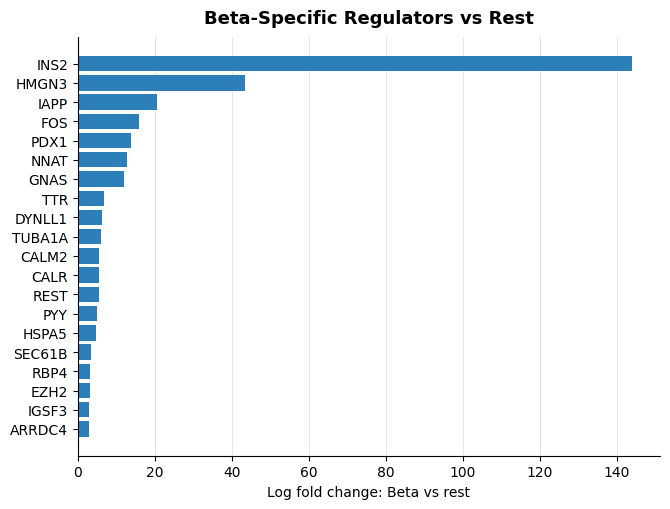

In [12]:
top_to_plot = beta_specific_tfs.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.barh(top_to_plot["regulator"], top_to_plot["logfoldchanges"], color="#2C7FB8")
ax.set_xlabel("Log fold change: Beta vs rest")
ax.set_ylabel("")
ax.set_title("Beta-Specific Regulators vs Rest", fontsize=13, weight="bold", pad=10)
ax.grid(axis="x", color="#E6E6E6", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "beta_specific_tfs_vs_rest.png", dpi=300, bbox_inches="tight")
plt.show()


## TF Top Target Genes

Cell-type mean attention networks can also be used to inspect the strongest target genes for a selected regulator. The example below uses the Beta mean attention network exported from the provided stage-1 pancreas checkpoint and retrieves the top 25 targets of PDX1.


In [ ]:
reference_genes = [line.strip().upper() for line in GENE_ORDER.read_text().splitlines() if line.strip()]
gene_to_idx = {gene: idx for idx, gene in enumerate(reference_genes)}

beta_mean_attention = sparse.load_npz(BETA_MEAN_ATTENTION_NPZ).toarray()
if beta_mean_attention.shape != (len(reference_genes), len(reference_genes)):
    raise ValueError(
        f"Beta attention matrix shape {beta_mean_attention.shape} does not match gene order length {len(reference_genes)}"
    )

def rank_tf_targets_from_mean_attention(matrix, genes, tf_gene, top_k=25):
    tf_key = tf_gene.upper()
    if tf_key not in gene_to_idx:
        raise KeyError(f"{tf_gene} is not present in the reference gene order")
    tf_idx = gene_to_idx[tf_key]
    weights = np.asarray(matrix[:, tf_idx], dtype=float)
    order = np.argsort(-weights)
    rows = []
    for target_idx in order:
        target = genes[target_idx]
        if target == tf_key:
            continue
        rows.append({
            "rank": len(rows) + 1,
            "regulator": title_case_gene(tf_key),
            "target_gene": title_case_gene(target),
            "target_gene_upper": target,
            "weight": weights[target_idx],
        })
        if len(rows) >= top_k:
            break
    return pd.DataFrame(rows)

pdx1_beta_top25 = rank_tf_targets_from_mean_attention(beta_mean_attention, reference_genes, "PDX1", top_k=25)
pdx1_beta_top25.to_csv(FIGURE_DIR / "beta_pdx1_top25_targets.csv", index=False)
display(pdx1_beta_top25)


In [ ]:
plot_df = pdx1_beta_top25.iloc[::-1]
fig, ax = plt.subplots(figsize=(6.8, 6.0))
ax.barh(plot_df["target_gene"], plot_df["weight"], color="#E67E22")
ax.set_xlabel("Mean attention weight from PDX1")
ax.set_ylabel("")
ax.set_title("PDX1 Top Targets in Beta Cells", fontsize=13, weight="bold", pad=10)
ax.grid(axis="x", color="#E6E6E6", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "beta_pdx1_top25_targets.png", dpi=300, bbox_inches="tight")
plt.show()
